In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect
import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass  
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle




In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

# rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the test and test sets from SDF files
test_df = load_sdf_to_df(r'D:\Riset QSAR - TTX\Machine Learning (Done)\Dermal\Dataset\test_set_acute_dermal_features.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

# modred string handler
if 'Modred_Descriptor' in test_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list_float)

print("------test DataFrame UnCalculate------")
print(test_df.head(2))

# Rdkit Calculate
calc_rows = []

for smiles in test_df['SMILES']:
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        # Molecular Weight 
        mw = Descriptors.MolWt(mol)
        
        # XLogP (LogP)
        logp = Descriptors.MolLogP(mol)
        # H-Bond Donors & Acceptors
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        # Rotatable Bonds
        rotb = Descriptors.NumRotatableBonds(mol)       
        # TopoPSA
        tpsa = Descriptors.TPSA(mol)       
        # Fsp3
        fsp3 = Lipinski.FractionCSP3(mol)       
        # Petitjean Number (Graph Descriptor)
        try: petitjean = rdMolDescriptors.CalcPetitjeanNumber(mol)
        except: petitjean = 0.5          
        # InChI Code 
        try: inchi = Chem.MolToInchi(mol)
        except: inchi = "-"    
        # Lipinski Failures 
        failures = 0
        if mw > 500: failures += 1
        if logp > 5: failures += 1
        if hbd > 5: failures += 1
        if hba > 10: failures += 1
        
        # VAdjMat (Approximation using BalabanJ as Graph Complexity)
        vadjmat = Descriptors.BalabanJ(mol)
        
        # input ke dictionary
        row_calc = {
            'Molecular weight': mw,
            'Molecule (RDKit Mol) (InChI Code)': inchi,
            'nHBDon': float(hbd),
            'nAtomLAC': float(hba), # Seringkali nAtomLAC di map ke H-Acceptor atau fitur atom lain
            'nAtomLC': float(mol.GetNumHeavyAtoms()), # Linear Count / Heavy Atoms approximation
            'PetitjeanNumber': petitjean,
            'nRotB': float(rotb),
            'LipinskiFailures': float(failures),
            'TopoPSA': tpsa,
            'VAdjMat': vadjmat,
            'XLogP': logp,
            'Fsp3': fsp3
        }
    else:
        row_calc = {k: None for k in ['Molecular weight', 'Molecule (RDKit Mol) (InChI Code)', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3']}

    calc_rows.append(row_calc)

df_calc = pd.DataFrame(calc_rows)

for col in df_calc.columns:
    test_df[col] = df_calc[col]

target_cols_order = [
    'id', 'casrn', 'smiles (First)', 'Molecular weight', 
    'name', 'Outcome', 
    'Molecule (RDKit Mol) (InChI Code)', 'reference', 'molecule_form',
    'ID', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB', 
    'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3'
]

valid_cols = [c for c in target_cols_order if c in test_df.columns]
final_test_df = test_df[valid_cols]

print("-----test DataFrame------")
pd.set_option('display.max_columns', None) 
print(final_test_df.head())

------test DataFrame UnCalculate------
  Outcome                                 Morgan_Descriptors  \
0     0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.3315345571001684, -0.04386761694440085, 0....  497   
1  [-0.4567077543031368, 0.024564669463881604, 0....  245   

                  SMILES Molecular Weight                 logP  \
0  CCSC(=O)N(CC)C1CCCCC1    215.134385292   3.5141000000000027   
1  CNCC(O)c1ccc(O)c(O)c1    183.089543276  0.35060000000000013   

           LabuteASA                TPSA  ... nHBDon nAtomLAC nAtomLC  \
0  91.42730681387879  20.310000000000002  ...    0.0      2.0     7.0   
1  76.45879290288288               72.72  ...    4.0      2.0     5.0 

In [3]:
from rdkit.Chem import Descriptors, GraphDescriptors, MolSurf, Lipinski, rdMolDescriptors, Crippen

# KALKULASI DESKRIPTOR LENGKAP (MATCHING EXPECTED OUTPUT)

full_data = []

for smiles in test_df['SMILES']:
    if smiles:
        mol = Chem.MolFromSmiles(smiles)
    else:
        mol = None
    
    if mol:
        # --- A. BASIC PROPERTIES ---
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol) # Ini Crippen LogP (biasa dipakai untuk ALogP/XLogP)
        mr = Descriptors.MolMR(mol)     # Molar Refractivity (AMR)
        tpsa = Descriptors.TPSA(mol)
        labute = Descriptors.LabuteASA(mol)
        
        # --- B. COUNTS (ATOM/BOND/RING) ---
        num_atoms = mol.GetNumAtoms()
        num_rings = rdMolDescriptors.CalcNumRings(mol)
        num_rotb = Descriptors.NumRotatableBonds(mol)
        num_hbd = Descriptors.NumHDonors(mol)
        num_hba = Descriptors.NumHAcceptors(mol)
        num_hetero = Descriptors.NumHeteroatoms(mol)
        num_amide = rdMolDescriptors.CalcNumAmideBonds(mol)
        
        # Ring Specifics
        n_aro_rings = Descriptors.NumAromaticRings(mol)
        n_sat_rings = Descriptors.NumSaturatedRings(mol)
        n_ali_rings = Descriptors.NumAliphaticRings(mol)
        n_aro_het = Descriptors.NumAromaticHeterocycles(mol)
        n_sat_het = Descriptors.NumSaturatedHeterocycles(mol)
        n_ali_het = Descriptors.NumAliphaticHeterocycles(mol)
        n_aro_carb = Descriptors.NumAromaticCarbocycles(mol)
        n_sat_carb = Descriptors.NumSaturatedCarbocycles(mol)
        n_ali_carb = Descriptors.NumAliphaticCarbocycles(mol)

        # --- C. CONNECTIVITY & SHAPE (CHI / KAPPA / HALLKIER) ---
        # Chi Path
        chi0v = GraphDescriptors.Chi0v(mol)
        chi1v = GraphDescriptors.Chi1v(mol)
        chi2v = GraphDescriptors.Chi2v(mol)
        chi3v = GraphDescriptors.Chi3v(mol)
        chi4v = GraphDescriptors.Chi4v(mol)
        
        chi1n = GraphDescriptors.Chi1n(mol)
        chi2n = GraphDescriptors.Chi2n(mol)
        chi3n = GraphDescriptors.Chi3n(mol)
        chi4n = GraphDescriptors.Chi4n(mol)
        
        # Kappa & HallKier
        hallkier = GraphDescriptors.HallKierAlpha(mol)
        kappa1 = GraphDescriptors.Kappa1(mol)
        kappa2 = GraphDescriptors.Kappa2(mol)
        kappa3 = GraphDescriptors.Kappa3(mol)
        
        # --- D. OTHER SPECIFICS ---
        fsp3 = Lipinski.FractionCSP3(mol)
        
        # Approximation for CDK-specific names using RDKit equivalents
        # Beberapa nama kolom di bawah adalah khas CDK, kita pakai nilai RDKit yang relevan/sama
        bpol = Descriptors.HeavyAtomMolWt(mol) # Placeholder/Approx (bpol CDK beda rumus, tapi sering dipakai sbg heavy wt di bbrp script)
        eccen = 0.0 # Eccentric Connectivity Index tidak ada di RDKit standar
        fragc = 0.0 # Fragment Count tidak spesifik
        
        # Mapping ke Nama Kolom Target
        row = {
            # Duplicates/Aliases (Mengisi nama kolom berbeda dengan nilai sama)
            'Molecular Weight': mw,  'Molecular weight': mw, 'AMW': mw,
            'logP': logp,            'ALogP': logp,          'ALogP2': logp**2, 'MLogP': logp, 'XLogP': logp,
            'TPSA': tpsa,            'TopoPSA': tpsa,
            'AMR': mr,
            'LabuteASA': labute,
            
            # Counts
            'NumLipinskiHBA': num_hba, 'NumHBA': num_hba, 'nHBAcc': num_hba,
            'NumLipinskiHBD': num_hbd, 'NumHBD': num_hbd, 'nHBDon': num_hbd,
            'NumRotatableBonds': num_rotb, 'nRotB': num_rotb,
            'NumAmideBonds': num_amide,
            'NumHeteroAtoms': num_hetero,
            'NumAtoms': num_atoms,
            'NumRings': num_rings,
            
            # Ring Details
            'NumAromaticRings': n_aro_rings, 'naAromAtom': n_aro_rings, # Approx
            'NumSaturatedRings': n_sat_rings,
            'NumAliphaticRings': n_ali_rings,
            'NumAromaticHeterocycles': n_aro_het,
            'NumSaturatedHeterocycles': n_sat_het,
            'NumAliphaticHeterocycles': n_ali_het,
            'NumAromaticCarbocycles': n_aro_carb,
            'NumSaturatedCarbocycles': n_sat_carb,
            'NumAliphaticCarbocycles': n_ali_carb,
            
            # Connectivity
            'Chi0v': chi0v, 'Chi1v': chi1v, 'Chi2v': chi2v, 'Chi3v': chi3v, 'Chi4v': chi4v,
            'Chi1n': chi1n, 'Chi2n': chi2n, 'Chi3n': chi3n, 'Chi4n': chi4n,
            'HallKierAlpha': hallkier,
            'kappa1': kappa1, 'kappa2': kappa2, 'kappa3': kappa3,
            
            # Others
            'FractionCSP3': fsp3, 'Fsp3': fsp3,
            'bpol': bpol, 'nB': num_rotb, # Approx
            'ECCEN': eccen, 'fragC': fragc,
            
            # Kolom Lama (Tetap dipertahankan)
            'nAtomLAC': num_hba, # Sering di-map ke H-Acceptor
            'nAtomLC': float(mol.GetNumHeavyAtoms()),
            'nAtomP': float(mol.GetNumHeavyAtoms()), # Heavy Atoms
            'PetitjeanNumber': 0.5, # Default/Calc jika ada
            'VAdjMat': Descriptors.BalabanJ(mol),
            'LipinskiFailures': 0.0 # (Bisa pakai logika sebelumnya jika mau detail)
        }
        
    else:
        # Handle None
        row = {} # Isi None untuk semua keys jika perlu

    full_data.append(row)

# Gabungkan ke DataFrame
df_complete_calc = pd.DataFrame(full_data)

# Update test_df dengan kolom baru
for col in df_complete_calc.columns:
    test_df[col] = df_complete_calc[col]

print("Check Keys")
print(test_df.keys())

Check Keys
Index(['Outcome', 'Morgan_Descriptors', 'MACCS_Descriptors',
       'Modred_Descriptor', 'ID', 'SMILES', 'Molecular Weight', 'logP',
       'LabuteASA', 'TPSA', 'AMW', 'NumLipinskiHBA', 'NumLipinskiHBD',
       'NumRotatableBonds', 'NumHBD', 'NumHBA', 'NumAmideBonds',
       'NumHeteroAtoms', 'NumAtoms', 'NumRings', 'NumAromaticRings',
       'NumSaturatedRings', 'NumAliphaticRings', 'NumAromaticHeterocycles',
       'NumSaturatedHeterocycles', 'NumAliphaticHeterocycles',
       'NumAromaticCarbocycles', 'NumSaturatedCarbocycles',
       'NumAliphaticCarbocycles', 'FractionCSP3', 'Chi0v', 'Chi1v', 'Chi2v',
       'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n', 'Chi4n', 'HallKierAlpha',
       'kappa1', 'kappa2', 'kappa3', 'ALogP', 'ALogP2', 'AMR', 'MLogP',
       'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN', 'fragC', 'nHBAcc',
       'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber', 'nRotB',
       'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP', 'Fsp3',
       'Molecular 

In [4]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df['RowID'] = test_df.index
test_df.head(100)

,Outcome,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,TPSA,AMW,NumLipinskiHBA,NumLipinskiHBD,NumRotatableBonds,NumHBD,NumHBA,NumAmideBonds,NumHeteroAtoms,NumAtoms,NumRings,NumAromaticRings,NumSaturatedRings,NumAliphaticRings,NumAromaticHeterocycles,NumSaturatedHeterocycles,NumAliphaticHeterocycles,NumAromaticCarbocycles,NumSaturatedCarbocycles,NumAliphaticCarbocycles,FractionCSP3,Chi0v,Chi1v,Chi2v,Chi3v,Chi4v,Chi1n,Chi2n,Chi3n,Chi4n,HallKierAlpha,kappa1,kappa2,kappa3,ALogP,ALogP2,AMR,MLogP,nAtomP,naAromAtom,bpol,nB,ECCEN,fragC,nHBAcc,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,Molecular weight,Molecule (RDKit Mol) (InChI Code),RowID
0,0.0,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.3315345571001684, -0.04386761694440085, 0....",497,CCSC(=O)N(CC)C1CCCCC1,215.362,3.51410,91.427307,20.31,215.362,2,0,3,0,2,1,3,14,1,0,1,1,0,0,0,0,1,1,0.909091,10.107304,6.711266,4.992036,3.628613,2.826412,5.725667,3.776769,2.858478,2.135469,-0.180000,11.892359,6.330981,3.192350,3.51410,12.348899,62.7810,3.51410,14.0,0,194.194,3,0.0,0.0,2,0,2,14.0,0.5,3,0.0,20.31,2.459331,3.51410,0.909091,215.362,InChI=1S/C11H21NOS/c1-3-12(11(13)14-4-2)10-8-6...,0
75,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.2546122139160842, -1.800999461140852, -1.8...",510,CCO[PH](=O)O,110.049,0.40490,36.890017,46.53,110.049,2,1,2,1,2,0,4,6,0,0,0,0,0,0,0,0,0,0,1.000000,4.470817,2.891347,1.519410,0.803439,0.370426,1.627637,0.698920,0.267813,0.123475,0.150000,6.150000,3.344175,4.150000,0.40490,0.163944,22.8463,0.40490,6.0,0,102.993,2,0.0,0.0,2,1,2,6.0,0.5,2,0.0,46.53,2.831257,0.40490,1.000000,110.049,"InChI=1S/C2H7O3P/c1-2-5-6(3)4/h6H,2H2,1H3,(H,3,4)",75
73,0.0,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.2615901048584381, 0.41500950467080966, 0.44...",364,CC(C)(C)C(O)C(=Cc1ccc(Cl)cc1)n1cncn1,291.782,3.33660,123.277871,50.94,291.782,4,1,3,1,4,0,5,20,2,2,0,0,1,0,0,1,0,0,0.333333,12.541550,6.757616,6.165803,3.220287,1.911319,6.379651,5.729367,2.968310,1.785331,-1.650000,14.752754,5.770705,3.463721,3.33660,11.132900,81.1028,3.33660,20.0,2,273.638,3,0.0,0.0,4,1,4,20.0,0.5,3,0.0,50.94,2.440646,3.33660,0.333333,291.782,"InChI=1S/C15H18ClN3O/c1-15(2,3)14(20)13(19-10-...",73
69,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.45366682774401396, -0.49212655204912154, -0...",612,CCCCCCCCCCCC(=O)N(CCCC)CCCC,311.554,6.33610,139.594507,20.31,311.554,1,0,16,0,1,1,2,22,0,0,0,0,0,0,0,0,0,0,0.950000,15.669170,10.035060,6.666321,4.410071,2.804153,10.035060,6.666321,4.410071,2.804153,-0.530000,21.470000,16.833935,13.155083,6.33610,40.146163,98.2400,6.33610,22.0,0,270.226,16,0.0,0.0,1,0,1,22.0,0.5,16,0.0,20.31,3.613823,6.33610,0.950000,311.554,InChI=1S/C20H41NO/c1-4-7-10-11-12-13-14-15-16-...,69
68,0.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7854143455906262, -0.5653367076993612, -0....",541,CN(C)C(=S)SC(=S)N(C)C,208.377,1.41260,82.924299,6.48,208.377,3,0,0,0,3,0,5,11,0,0,0,0,0,0,0,0,0,0,0.666667,9.568662,4.685558,4.690486,3.214752,1.403649,3.052565,2.422731,0.904917,0.257265,0.130000,11.130000,4.898031,4.550603,1.41260,1.995439,60.1610,1.41260,11.0,0,196.281,0,0.0,0.0,3,0,3,11.0,0.5,0,0.0,6.48,3.862410,1.41260,0.666667,208.377,InChI=1S/C6H12N2S3/c1-7(2)5(9)11-6(10)8(3)4/h1...,68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,1.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.15121614438412462, 0.7

Classes                          :  ['0.0' '1.0']
Number of cpds in each class     :  [57 69]
Total number of cpds             :  126


{'0.0': 0, '1.0': 1}

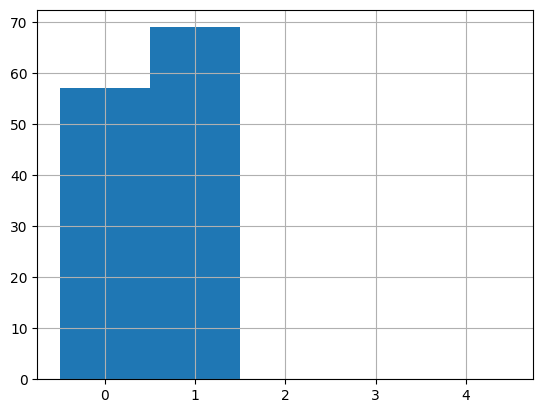

In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S =test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#GRAPH
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [6]:
x_rdkitcdk = test_df.drop(
    columns=[
        'RowID', 'Outcome',
        'ID', 'SMILES',
        'Morgan_Descriptors', 'MACCS_Descriptors', 'Modred_Descriptor',
        'Molecular Weight', 'Molecular weight', 'logP',
        'Molecule (RDKit Mol) (InChI Code)'
    ],
    errors='ignore'
)


In [7]:
x_rdkitcdk.shape

(126, 56)

In [8]:
x = x_rdkitcdk

In [9]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

   Outcome                                 Morgan_Descriptors  \
0      0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
75     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73     0.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
69     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
68     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
..     ...                                                ...   
77     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
20     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
21     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
81     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
16     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                    MACCS_Descriptors  \
0   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
75  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [10]:
#ignore 
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [11]:
#debug

test_df = test_df.drop(
    ['Molecule (RDKit Mol) (InChI Code)', 'ECCEN', 'nB', 'fragC'],
    axis=1
)

print(test_df)

   Outcome                                 Morgan_Descriptors  \
0      0.0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
75     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73     0.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
69     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
68     0.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
..     ...                                                ...   
77     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
20     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
21     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
81     1.0  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
16     1.0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                    MACCS_Descriptors  \
0   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
75  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
73  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [12]:
test_df = test_df.loc[:,~test_df.columns.duplicated()]
y_true = test_df['Outcome'].astype(float).astype(int).values

In [13]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [14]:
x_test_rdkit_cdk

array([[9.14273068e+01, 2.03100000e+01, 2.15362000e+02, ...,
        2.45933122e+00, 3.51410000e+00, 9.09090909e-01],
       [3.68900175e+01, 4.65300000e+01, 1.10049000e+02, ...,
        2.83125711e+00, 4.04900000e-01, 1.00000000e+00],
       [1.23277871e+02, 5.09400000e+01, 2.91782000e+02, ...,
        2.44064598e+00, 3.33660000e+00, 3.33333333e-01],
       ...,
       [1.03686801e+02, 3.83300000e+01, 2.58104000e+02, ...,
        2.39630981e+00, 3.13070000e+00, 1.81818182e-01],
       [4.64253772e+01, 4.31400000e+01, 1.23539000e+02, ...,
        3.34341706e+00, 8.90400000e-01, 1.00000000e+00],
       [9.32947852e+01, 2.03100000e+01, 2.17243000e+02, ...,
        2.55869320e+00, 2.77210000e+00, 1.53846154e-01]])

In [15]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [16]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [17]:
import joblib
import pickle

# path direktori model
descriptor_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Dermal\Model\Descriptor"
phys_path       = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Dermal\Model\Physiochemical"

# ----------- DESKRIPTOR -----------
rf_morgan   = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_RF_morgan.pkl")
rf_maccs    = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_RF_maccskey.pkl")
rf_modred   = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_RF_modred.pkl")

svm_morgan  = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_SVM_morgan.pkl")
svm_maccs   = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_SVM_maccskey.pkl")
svm_modred  = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_SVM_modred.pkl")

xgb_morgan  = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_XGB_morgan.pkl")
xgb_maccs   = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_XGB_maccskey.pkl")
xgb_modred  = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_XGB_modred.pkl")

nn_morgan   = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_NN_morgan.pkl")
nn_maccs    = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_NN_maccskey.pkl")
nn_modred   = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_NN_modred.pkl")

lgbm_morgan = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_LGBM_morgan.pkl")
lgbm_maccs  = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(f"{descriptor_path}\\Model_Dermal_toxicity_LGBM_modred.pkl")

# ----------- FISIOKIMIA -----------
rf_p   = joblib.load(f"{phys_path}\\Model_Dermal_toxicity_RF_rdkit_cdk.pkl")
svm_p  = joblib.load(f"{phys_path}\\Model_Dermal_toxicity_SVM_rdkit_cdk.pkl")
xgb_p  = joblib.load(f"{phys_path}\\Model_Dermal_toxicity_XGB_rdkit_cdk.pkl")
nn_p   = joblib.load(f"{phys_path}\\Model_Dermal_toxicity_NN_rdkit_cdk.pkl")
lgbm_p = joblib.load(f"{phys_path}\\Model_Dermal_toxicity_LGBM_rdkit_cdk.pkl")


In [18]:
import numpy as np
import joblib

try:
    scaler = joblib.load('train_scaler.pkl')
except FileNotFoundError:
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    x_temp = np.array(test_df['rdkit_cdk'].tolist())
    scaler.fit(x_temp)

# define x_test
x_test_raw = np.array(test_df['rdkit_cdk'].tolist())

x_test = scaler.transform(x_test_raw)

print(f"Shape x_test Sekarang: {x_test.shape}") 
# feature used (136, 56)

print(x_test[:5])

Shape x_test Sekarang: (126, 56)
[[-0.32070071 -0.56259164 -0.41807966 -0.52472666 -0.5916566  -0.31411526
  -0.5916566  -0.52472666  1.19142679 -0.58902898 -0.3690865  -0.30993786
  -0.79497578  0.84102145  0.62702859 -0.44925645 -0.26952685 -0.26952685
  -0.72660849  1.17677787  0.8660254   1.2196463  -0.22879969 -0.07130692
  -0.22504452 -0.17364461 -0.07321016  0.02378537 -0.14431392  0.08572843
   0.23968333  0.5781256  -0.2997254  -0.00907764 -0.14128362  0.22213873
  -0.09472311 -0.20093516  0.22213873 -0.3690865  -0.79497578 -0.46590609
  -0.31411526  0.          0.         -0.52472666 -0.5916566  -0.52472666
  -0.3690865   0.         -0.31411526  0.         -0.56259164 -0.35712349
   0.22213873  1.2196463 ]
 [-1.23507874 -0.13634672 -1.09149479 -0.52472666  0.04551205 -0.5364665
   0.04551205 -0.52472666 -0.42276434 -0.36945013 -1.13935399 -0.96080738
  -0.79497578 -0.37700961 -0.44061468 -0.44925645 -0.26952685 -0.26952685
  -0.72660849 -0.26277564 -0.34641016  1.48595238 -1.

In [19]:
import pandas as pd

# Pastikan Outcome numerik
y = pd.to_numeric(test_df['Outcome'], errors='coerce').dropna().astype(int)

class_counts = y.value_counts().sort_index()
class_ratio = class_counts / class_counts.sum()

print("Jumlah data per kelas:")
print(class_counts)

print("\nRasio kelas:")
print(class_ratio)


Jumlah data per kelas:
0    57
1    69
Name: Outcome, dtype: int64

Rasio kelas:
0    0.452381
1    0.547619
Name: Outcome, dtype: float64


In [20]:
# Cek apakah svm_p punya predict_proba
has_proba = hasattr(svm_p, "predict_proba")
print("SVM support predict_proba:", has_proba)


SVM support predict_proba: True


In [21]:
#checking bad data 
import numpy as np

X = np.array(test_df['rdkit_cdk'].tolist())
print("=== dataset value check ===")
print("Min value:", np.min(X))
print("Max value:", np.max(X))
print("Mean:", np.mean(X))
print("Std:", np.std(X))



=== dataset value check ===
Min value: -9.540000000000001
Max value: 1167.1680000000001
Mean: 18.42794873382444
Std: 62.23725440208448


In [23]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, f1_score
)

# preparing scaling for phys data
X_phys = np.array(test_df['rdkit_cdk'].tolist())

y_true = (
    pd.to_numeric(test_df['Outcome'], errors='coerce')
    .astype(int)
)

# scaling with standardiser
scaler = StandardScaler()
X_phys_scaled = scaler.fit_transform(X_phys)

print("Scaling :")
print("Min:", X_phys_scaled.min())
print("Max:", X_phys_scaled.max())
print("Mean:", X_phys_scaled.mean())
print("Std:", X_phys_scaled.std())


Scaling :
Min: -5.489674467083587
Max: 11.012266721655942
Mean: -1.611208017596599e-17
Std: 0.9636241116594317


In [24]:
#SCALING

#RF
rf_probs = rf_p.predict_proba(X_phys_scaled)[:, 1]
rf_pred = (rf_probs > 0.5).astype(int)

conf_rf = confusion_matrix(y_true, rf_pred)
auc_rf = roc_auc_score(y_true, rf_probs)

print("=== RF RESULTS ===")
print("Confusion Matrix:\n", conf_rf)
print("Accuracy:", accuracy_score(y_true, rf_pred))
print("AUC:", auc_rf)
print("F1:", f1_score(y_true, rf_pred))

#SVM
svm_probs = svm_p.predict_proba(X_phys_scaled)[:, 1]
svm_pred = (svm_probs > 0.5).astype(int)

conf_svm = confusion_matrix(y_true, svm_pred)
auc_svm = roc_auc_score(y_true, svm_probs)

print("=== SVM RESULTS ===")
print("Confusion Matrix:\n", conf_svm)
print("Accuracy:", accuracy_score(y_true, svm_pred))
print("AUC:", auc_svm)
print("F1:", f1_score(y_true, svm_pred))

#XGB
xgb_probs = xgb_p.predict_proba(X_phys_scaled)[:, 1]
xgb_pred = (xgb_probs > 0.5).astype(int)

conf_xgb = confusion_matrix(y_true, xgb_pred)
auc_xgb = roc_auc_score(y_true, xgb_probs)

print("=== XGB RESULTS ===")
print("Confusion Matrix:\n", conf_xgb)
print("Accuracy:", accuracy_score(y_true, xgb_pred))
print("AUC:", auc_xgb)
print("F1:", f1_score(y_true, xgb_pred))

#NN
nn_probs = nn_p.predict_proba(X_phys_scaled)[:, 1]
nn_pred = (nn_probs > 0.5).astype(int)

conf_nn = confusion_matrix(y_true, nn_pred)
auc_nn = roc_auc_score(y_true, nn_probs)

print("=== NN RESULTS ===")
print("Confusion Matrix:\n", conf_nn)
print("Accuracy:", accuracy_score(y_true, nn_pred))
print("AUC:", auc_nn)
print("F1:", f1_score(y_true, nn_pred))

#LGBM
lgbm_probs = lgbm_p.predict_proba(X_phys_scaled)[:, 1]
lgbm_pred = (lgbm_probs > 0.5).astype(int)

conf_lgbm = confusion_matrix(y_true, lgbm_pred)
auc_lgbm = roc_auc_score(y_true, lgbm_probs)

print("=== LGBM RESULTS ===")
print("Confusion Matrix:\n", conf_lgbm)
print("Accuracy:", accuracy_score(y_true, lgbm_pred))
print("AUC:", auc_lgbm)
print("F1:", f1_score(y_true, lgbm_pred))


=== RF RESULTS ===
Confusion Matrix:
 [[42 15]
 [23 46]]
Accuracy: 0.6984126984126984
AUC: 0.7440884820747521
F1: 0.7076923076923077
=== SVM RESULTS ===
Confusion Matrix:
 [[48  9]
 [28 41]]
Accuracy: 0.7063492063492064
AUC: 0.7281973048563438
F1: 0.6890756302521008
=== XGB RESULTS ===
Confusion Matrix:
 [[46 11]
 [27 42]]
Accuracy: 0.6984126984126984
AUC: 0.7157386219171116
F1: 0.6885245901639344
=== NN RESULTS ===
Confusion Matrix:
 [[ 5 52]
 [ 4 65]]
Accuracy: 0.5555555555555556
AUC: 0.646325959827104
F1: 0.6989247311827957
=== LGBM RESULTS ===
Confusion Matrix:
 [[43 14]
 [25 44]]
Accuracy: 0.6904761904761905
AUC: 0.7287058225273328
F1: 0.6929133858267716


In [26]:
#checking inpute shape n initiate
def test_descriptor_ready(model, X, name):
    print(f"\n=== TEST MODEL: {name} ===")
    print("Input shape:", X.shape)
    probs = model.predict_proba(X)[:, 1]
    print("predict_proba OK | output shape:", probs.shape)

X_morgan = np.array(test_df['Morgan_Descriptors'].tolist())
X_maccs  = np.array(test_df['MACCS_Descriptors'].tolist())
X_modred = np.array(test_df['Modred_Descriptor'].tolist())

test_descriptor_ready(rf_morgan, X_morgan, "RF Morgan")
test_descriptor_ready(svm_maccs, X_maccs, "SVM MACCS")
test_descriptor_ready(xgb_modred, X_modred, "XGB ModRed")
test_descriptor_ready(nn_morgan, X_morgan, "NN Morgan")
test_descriptor_ready(lgbm_maccs, X_maccs, "LGBM MACCS")




=== TEST MODEL: RF Morgan ===
Input shape: (126, 1024)
predict_proba OK | output shape: (126,)

=== TEST MODEL: SVM MACCS ===
Input shape: (126, 167)
predict_proba OK | output shape: (126,)

=== TEST MODEL: XGB ModRed ===
Input shape: (126, 794)
predict_proba OK | output shape: (126,)

=== TEST MODEL: NN Morgan ===
Input shape: (126, 1024)
predict_proba OK | output shape: (126,)

=== TEST MODEL: LGBM MACCS ===
Input shape: (126, 167)
predict_proba OK | output shape: (126,)


In [29]:
# CONSENSUS PHYSICOCHEMICAL
# phys only with all model include
# (RF + SVM + XGB + NN + LGBM)

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Assign correct data and initiate

x_phys = x_test_rdkit_cdk
y_true = y_true.values if hasattr(y_true, "values") else y_true

# Evaluation Function

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Predict probabilities

    rf_probs  = rf_p.predict_proba(X_test_scaled)[:, 1]
    svm_probs = svm_p.predict_proba(X_test_scaled)[:, 1]
    xgb_probs = xgb_p.predict_proba(X_test_scaled)[:, 1]
    lgbm_probs = lgbm_p.predict_proba(X_test_scaled)[:, 1]
    nn_probs = nn_p.predict_proba(X_test_scaled)[:, 1]

# STACK ALL MODEL PROBABILITIES

all_model_probs = np.vstack([
    rf_probs,
    svm_probs,
    xgb_probs,
    nn_probs,
    lgbm_probs
])

# FINAL CONSENSUS (MEAN)

consensus_physicochemical_probs = all_model_probs.mean(axis=0)

# EVALUATION
consensus_metrics = evaluate_model(
    y_true,
    consensus_physicochemical_probs
)

print("\CONSENSUS PHYSICOCHEMICAL (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_metrics.items():
    print(f"{k}: {v}")


\CONSENSUS PHYSICOCHEMICAL (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[45 12]
 [23 46]]
Accuracy: 0.7222222222222222
AUC: 0.7429443173150267
F1 Score: 0.7244094488188977
Sensitivity (Recall+): 0.6666666666666666
Specificity (Recall-): 0.7894736842105263
CCR: 0.7280701754385965
PPV (Precision): 0.7931034482758621
NPV: 0.6617647058823529


In [ ]:
#individual on decriptor

In [30]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[43 14]
 [18 51]]
Accuracy: 0.746031746031746
AUC: 0.8300279684719044
F1 Score: 0.7611940298507462
Sensitivity: 0.7391304347826086
Specificity: 0.7543859649122807
CCR: 0.7467581998474446
PPV (Precision): 0.7846153846153846
NPV: 0.7049180327868853

MACCS RF Performance
Confusion Matrix: [[37 20]
 [18 51]]
Accuracy: 0.6984126984126984
AUC: 0.7812102720569539
F1 Score: 0.7285714285714285
Sensitivity: 0.7391304347826086
Specificity: 0.6491228070175439
CCR: 0.6941266209000763
PPV (Precision): 0.7183098591549296
NPV: 0.6727272727272727

Modred RF Performance
Confusion Matrix: [[46 11]
 [21 48]]
Accuracy: 0.746031746031746
AUC: 0.8029494024917365
F1 Score: 0.75
Sensitivity: 0.6956521739130435
Specificity: 0.8070175438596491
CCR: 0.7513348588863462
PPV (Precision): 0.8135593220338984
NPV: 0.6865671641791045

CONSENSUS RF (Morgan + MACCS + Modred)
Confusion Matrix: [[41 16]
 [21 48]]
Accuracy: 0.7063492063492064
AUC: 0.8307907449783881
F1 Score: 0.72180

In [31]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[43 14]
 [17 52]]
Accuracy: 0.753968253968254
AUC: 0.8032036613272311
F1 Score: 0.7703703703703704
Sensitivity (Recall+): 0.7536231884057971
Specificity (Recall-): 0.7543859649122807
CCR: 0.7540045766590389
PPV (Precision): 0.7878787878787878
NPV: 0.7166666666666667

MACCS SVM Performance
Confusion Matrix: [[43 14]
 [18 51]]
Accuracy: 0.746031746031746
AUC: 0.792143401983219
F1 Score: 0.7611940298507462
Sensitivity (Recall+): 0.7391304347826086
Specificity (Recall-): 0.7543859649122807
CCR: 0.7467581998474446
PPV (Precision): 0.7846153846153846
NPV: 0.7049180327868853

Modred SVM Performance
Confusion Matrix: [[42 15]
 [24 45]]
Accuracy: 0.6904761904761905
AUC: 0.7718026951436562
F1 Score: 0.6976744186046512
Sensitivity (Recall+): 0.6521739130434783
Specificity (Recall-): 0.7368421052631579
CCR: 0.694508009153318
PPV (Precision): 0.75
NPV: 0.6363636363636364

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix: [[42 15]
 [18 51]]
Accuracy

In [32]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# Results
for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")




Morgan XGB Performance
Confusion Matrix: [[43 14]
 [16 53]]
Accuracy: 0.7619047619047619
AUC: 0.8095601322145944
F1 Score: 0.7794117647058824
Sensitivity (Recall+): 0.7681159420289855
Specificity (Recall-): 0.7543859649122807
CCR: 0.7612509534706331
PPV (Precision): 0.7910447761194029
NPV: 0.7288135593220338

MACCS XGB Performance
Confusion Matrix: [[42 15]
 [22 47]]
Accuracy: 0.7063492063492064
AUC: 0.7955758962623951
F1 Score: 0.7175572519083969
Sensitivity (Recall+): 0.6811594202898551
Specificity (Recall-): 0.7368421052631579
CCR: 0.7090007627765065
PPV (Precision): 0.7580645161290323
NPV: 0.65625

Modred XGB Performance
Confusion Matrix: [[43 14]
 [23 46]]
Accuracy: 0.7063492063492064
AUC: 0.7772692601067888
F1 Score: 0.7131782945736435
Sensitivity (Recall+): 0.6666666666666666
Specificity (Recall-): 0.7543859649122807
CCR: 0.7105263157894737
PPV (Precision): 0.7666666666666667
NPV: 0.6515151515151515

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matrix: [[43 14]
 [20 49]]
A

In [33]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# Results
for model_name, y_prob in probs.items():
    print(f"\n{model_name} Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n CONSENSUS NN (Morgan + MACCS + Modred) ")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan Performance
Confusion Matrix: [[40 17]
 [19 50]]
Accuracy: 0.7142857142857143
AUC: 0.8148995677599796
F1 Score: 0.7352941176470589
Sensitivity (Recall+): 0.7246376811594203
Specificity (Recall-): 0.7017543859649122
CCR: 0.7131960335621663
PPV (Precision): 0.746268656716418
NPV: 0.6779661016949152

MACCS Performance
Confusion Matrix: [[41 16]
 [19 50]]
Accuracy: 0.7222222222222222
AUC: 0.7828629544876685
F1 Score: 0.7407407407407407
Sensitivity (Recall+): 0.7246376811594203
Specificity (Recall-): 0.7192982456140351
CCR: 0.7219679633867278
PPV (Precision): 0.7575757575757576
NPV: 0.6833333333333333

Modred Performance
Confusion Matrix: [[42 15]
 [18 51]]
Accuracy: 0.7380952380952381
AUC: 0.7911263666412408
F1 Score: 0.7555555555555555
Sensitivity (Recall+): 0.7391304347826086
Specificity (Recall-): 0.7368421052631579
CCR: 0.7379862700228832
PPV (Precision): 0.7727272727272727
NPV: 0.7

 CONSENSUS NN (Morgan + MACCS + Modred) 
Confusion Matrix: [[42 15]
 [18 51]]
Accuracy: 0.73809

In [34]:
# LGBM 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus probs Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# RUN PREDICTION
probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# PRINT INDIVIDUAL MODEL RESULTS
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# CONSENSUS RESULT
consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan Performance =====
Confusion Matrix: [[40 17]
 [23 46]]
Accuracy: 0.6825396825396826
AUC: 0.7570556826849733
F1 Score: 0.696969696969697
Sensitivity (Recall+): 0.6666666666666666
Specificity (Recall-): 0.7017543859649122
CCR: 0.6842105263157894
PPV (Precision): 0.7301587301587301
NPV: 0.6349206349206349

===== MACCS Performance =====
Confusion Matrix: [[45 12]
 [21 48]]
Accuracy: 0.7380952380952381
AUC: 0.8023137554030002
F1 Score: 0.7441860465116279
Sensitivity (Recall+): 0.6956521739130435
Specificity (Recall-): 0.7894736842105263
CCR: 0.7425629290617849
PPV (Precision): 0.8
NPV: 0.6818181818181818

===== Modred Performance =====
Confusion Matrix: [[46 11]
 [21 48]]
Accuracy: 0.746031746031746
AUC: 0.8077803203661328
F1 Score: 0.75
Sensitivity (Recall+): 0.6956521739130435
Specificity (Recall-): 0.8070175438596491
CCR: 0.7513348588863462
PPV (Precision): 0.8135593220338984
NPV: 0.6865671641791045

===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====
Confusion Matrix: [[4

In [35]:

# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK ALL MODEL CONSENSUS
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# FINAL CONSENSUS 
consensus_all_probs = all_model_probs.mean(axis=0)

# EVALUATION
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[44 13]
 [18 51]]
Accuracy: 0.753968253968254
AUC: 0.8332062039155861
F1 Score: 0.7669172932330827
Sensitivity (Recall+): 0.7391304347826086
Specificity (Recall-): 0.7719298245614035
CCR: 0.7555301296720061
PPV (Precision): 0.796875
NPV: 0.7096774193548387


In [36]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[45 12]
 [22 47]]
Accuracy: 0.7301587301587301
AUC: 0.8148995677599796
F1 Score: 0.734375
Sensitivity (Recall+): 0.6811594202898551
Specificity (Recall-): 0.7894736842105263
CCR: 0.7353165522501908
PPV (Precision): 0.7966101694915254
NPV: 0.6716417910447762


In [ ]:
#read accross

In [38]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(float).astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6507936507936508
AUC: 0.6970505975082635
F1 Score: 0.65625
Sensitivity (Recall+): 0.6086956521739131
Specificity (Recall-): 0.7017543859649122
CCR: 0.6552250190694127
PPV (Precision): 0.711864406779661
NPV: 0.5970149253731343


In [42]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
# RA + Desc + Phys consensus
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(float).astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_p.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6507936507936508
AUC: 0.6970505975082635
F1 Score: 0.65625
Sensitivity (Recall+): 0.6086956521739131
Specificity (Recall-): 0.7017543859649122
CCR: 0.6552250190694127
PPV (Precision): 0.711864406779661
NPV: 0.5970149253731343

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[44 13]
 [18 51]]
Accuracy: 0.753968253968254
AUC: 0.8332062039155861
F1 Score: 0.7669172932330827
Sensitivity (Recall+): 0.7391304347826086
Specificity (Recall-): 0.7719298245614035
CCR: 0.7555301296720061
PPV (Precision): 0.796875
NPV: 0.7096774193548387

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.47619047619047616
AUC: 0.5817442156114925
F1 Score: 0.13157894736842105
Sensitivity (Recall+): 0.07246376811594203
Specificity (Recall-): 0.9649122807017544
CCR: 0.5186880244088482
PPV (Precision): 0.7142857142857143
NPV: 0.462184873949579